In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3069s 18us/step


# Explore Dataset

In [3]:
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


# Display Images

In [4]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

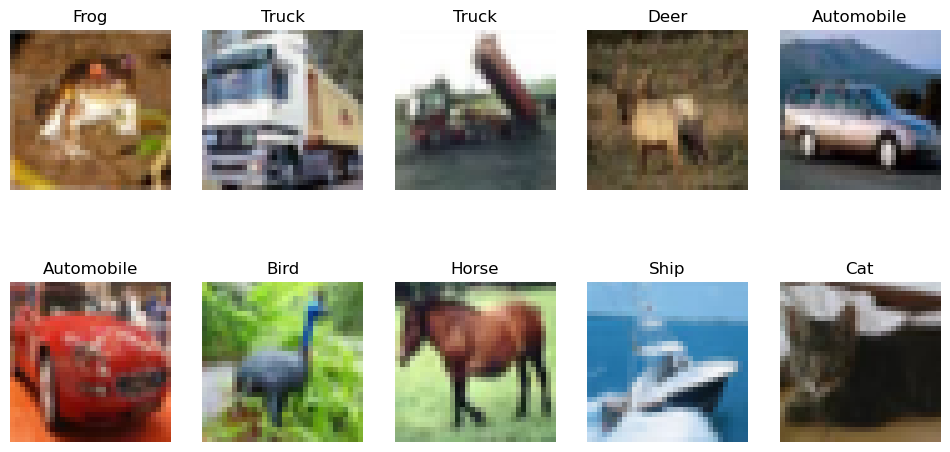

In [5]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.show()

In [6]:
y_train[i][0]

np.uint8(3)

# Normalize Images

In [7]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Build CNN Model

In [8]:
model = Sequential()

model.add(Input(shape=(32,32,3)))

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(10, activation="softmax"))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9074 - loss: 0.2561 - val_accuracy: 0.7541 - val_loss: 0.9797
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9112 - loss: 0.2445 - val_accuracy: 0.7544 - val_loss: 1.0407
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9164 - loss: 0.2338 - val_accuracy: 0.7577 - val_loss: 1.0457
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9182 - loss: 0.2210 - val_accuracy: 0.7554 - val_loss: 1.0586
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9240 - loss: 0.2119 - val_accuracy: 0.7466 - val_loss: 1.1701
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.9220 - loss: 0.2121 - val_accuracy: 0.7512 - val_loss: 1.1972
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9252 - loss: 0.2086 - val_accuracy: 0.7532 - val_loss: 1.1992
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9306 - loss: 0.1908 - 

# Evaluate Model

In [13]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7341 - loss: 1.4882
Loss : 1.4882099628448486
Accuracy : 0.7340999841690063


# Plot Accuracy and loss

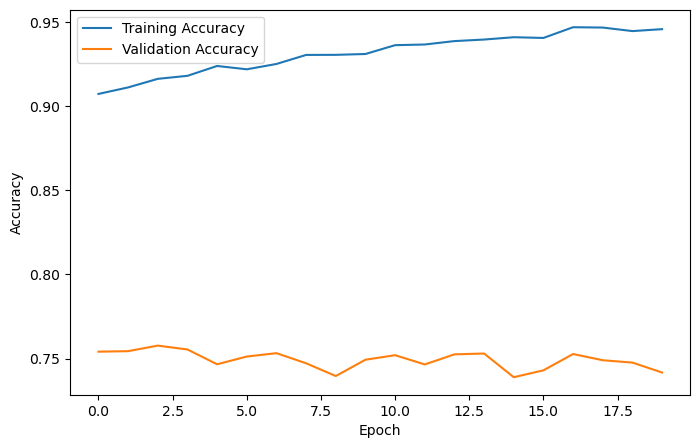

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

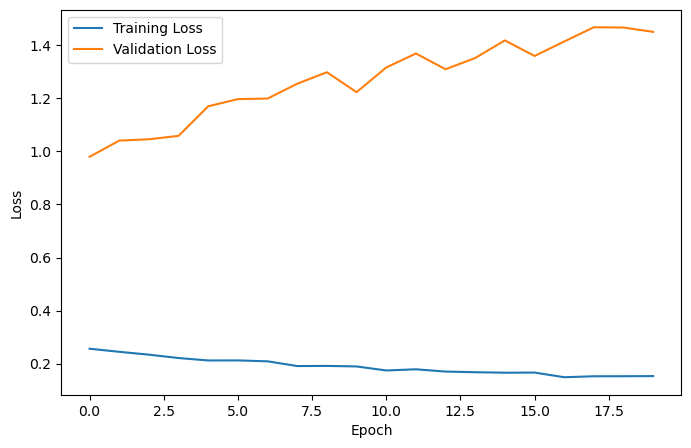

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Predict

In [16]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [17]:
predicted_class = np.argmax(predictions[0])

print("Predicted :", class_names[predicted_class])

print("Actual :", class_names[y_test[0][0]])

Predicted : Cat
Actual : Cat


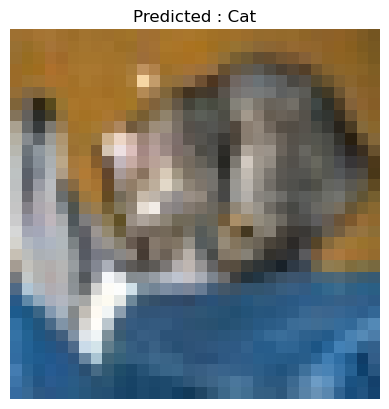

In [18]:
plt.imshow(x_test[0])

plt.title(
    f"Predicted : {class_names[predicted_class]}"
)

plt.axis("off")

plt.show()